In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [78]:
import os
import re
from glob import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

In [3]:

dataset_path = "/content/drive/MyDrive/Audio_project/HW1_M"

audio_files = glob(os.path.join(dataset_path, "*.mp3"))

file_data = []

filename_pattern = re.compile(r"HW\d+_Q\d+_(\d+)_(male|female)", re.IGNORECASE)

for file_path in audio_files:
    filename = os.path.basename(file_path)
    match = filename_pattern.match(filename)

    if match:
        student_id, gender = match.groups()
        file_data.append([filename, file_path, student_id, gender.lower()])

df_audio = pd.DataFrame(file_data, columns=["Filename", "Filepath", "Student_ID", "Gender"])

df_audio.head()


,Filename,Filepath,Student_ID,Gender
0,HW1_Q5_810801072_Male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810801072,male
1,HW1_Q3_810103262_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810103262,male
2,HW1_Q6_810600133_female.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810600133,female
3,HW1_Q4_159403005_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,159403005,male
4,HW1_Q1_810102345_male.mp3,/content/drive/MyDrive/Audio_project/HW1_M/HW1...,810102345,male


In [4]:
male_data = df_audio[df_audio["Gender"] == "male"]
female_data = df_audio[df_audio["Gender"] == "female"]

print("Number of Male Audio Files:", len(male_data))
print("Number of Female Audio Files:", len(female_data))


Number of Male Audio Files: 458
Number of Female Audio Files: 152


In [5]:
from tqdm import tqdm
tqdm.pandas()

# 1. Bandpass filter
def bandpass_filter(y, sr, lowcut=80.0 , highcut=3500.0, order=5):
    nyquist = 0.5 * sr
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y_filtered = lfilter(b, a, y)
    return y_filtered

# 2. Normalize audio
def normalize_audio(y):
    return y / np.max(np.abs(y))

# 3. Segment audio into fixed-length chunks
def segment_audio(y, sr, segment_length=2.0):
    segment_samples = int(segment_length * sr)
    return [y[i:i + segment_samples] for i in range(0, len(y), segment_samples) if len(y[i:i + segment_samples]) == segment_samples]

# 4. Preprocess and extract features
def preprocess_and_extract_features(file_path, n_mfcc=40, segment_length=2.0, target_sr=16000, max_length=60):

    y, sr = librosa.load(file_path, sr=None, duration=max_length)
    y = bandpass_filter(y, sr)  # Bandpass filter
    y = resample(y, int(len(y) * target_sr / sr))  # Resample
    sr = target_sr
    y = normalize_audio(y)  # Normalize
    segments = segment_audio(y, sr, segment_length)  # Segment audio

    # Extract features
    features = []
    for segment in segments:
        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc).mean(axis=1)
        zcr = librosa.feature.zero_crossing_rate(segment).mean()
        rms = librosa.feature.rms(y=segment).mean()
        spectral_centroid = librosa.feature.spectral_centroid(y=segment, sr=sr).mean()
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=segment, sr=sr).mean()
        spectral_contrast = librosa.feature.spectral_contrast(y=segment, sr=sr).mean()
        features.append(np.hstack([mfcc, zcr, rms, spectral_centroid, spectral_bandwidth, spectral_contrast]))

    return np.array(features)

# 5. Balance dataset
def balance_dataset(df):
    male_data = df[df["Gender"] == "male"]
    female_data = df[df["Gender"] == "female"]
    balanced_male_data = male_data.sample(len(female_data), random_state=42)  # Downsample males
    balanced_df = pd.concat([balanced_male_data, female_data]).reset_index(drop=True)
    return balanced_df


In [6]:
def select_random_students(df, num_batch=3, num_per_gender=5):
  male_ids = df[df['Gender'] == 'male']['Student_ID'].drop_duplicates().sample(n=num_batch * num_per_gender, random_state=42)

  female_ids = df[df['Gender'] == 'female']['Student_ID'].drop_duplicates().sample(n=num_batch * num_per_gender, random_state=42)

  df_batches = []
  for i in range(num_batch):
    df_batches.append(df[df['Student_ID'].isin(male_ids.tolist()[i * num_per_gender: (i + 1) * num_per_gender] + female_ids.tolist()[i * num_per_gender: (i + 1) * num_per_gender])])

  return df_batches

def make_dataset(df, segment_length=2.0, target_sr=16000, max_length=60):
  features = []
  labels = []
  class2label = {j: i for i, j in enumerate(df["Student_ID"].drop_duplicates())}
  for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing files"):
      file_path = row["Filepath"]
      label = class2label[row["Student_ID"]]
      try:
          file_features = preprocess_and_extract_features(file_path, segment_length=segment_length, target_sr=target_sr, max_length=max_length)
          for feature in file_features:
              features.append(feature)
              labels.append(label)
      except Exception as e:
          print(f"Error processing file {file_path}: {e}")
  return np.array(features), np.array(labels), class2label


In [69]:
df_batches = select_random_students(df_audio, 1, 5)

X, y, class2label = make_dataset(df_batches[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Processing files: 100%|██████████| 58/58 [01:28<00:00,  1.53s/it]


In [70]:
X_train.shape, y_train[:50]

((1304, 45),
 array([0, 4, 2, 1, 0, 3, 7, 8, 5, 1, 9, 9, 1, 6, 2, 5, 2, 0, 7, 3, 7, 8,
        3, 9, 8, 6, 5, 0, 9, 6, 1, 1, 5, 9, 7, 3, 0, 1, 9, 2, 3, 0, 8, 1,
        3, 6, 5, 1, 6, 4]))

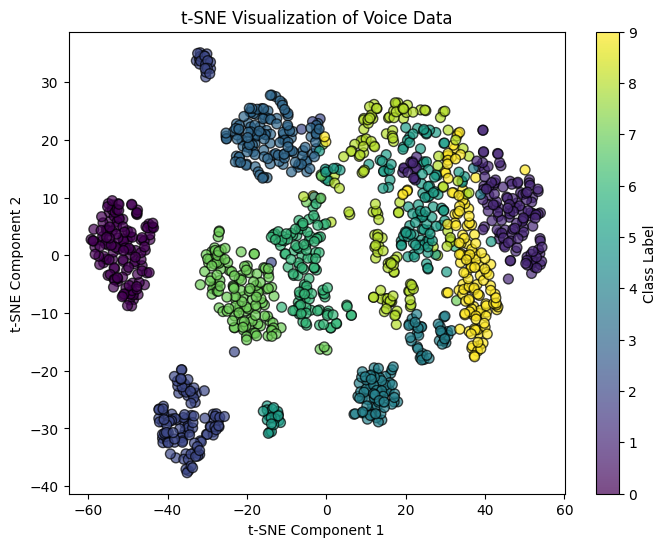

In [77]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap="viridis", edgecolor="k", s=50, alpha=0.7)
plt.title("t-SNE Visualization of Voice Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(label="Class Label")
plt.show()

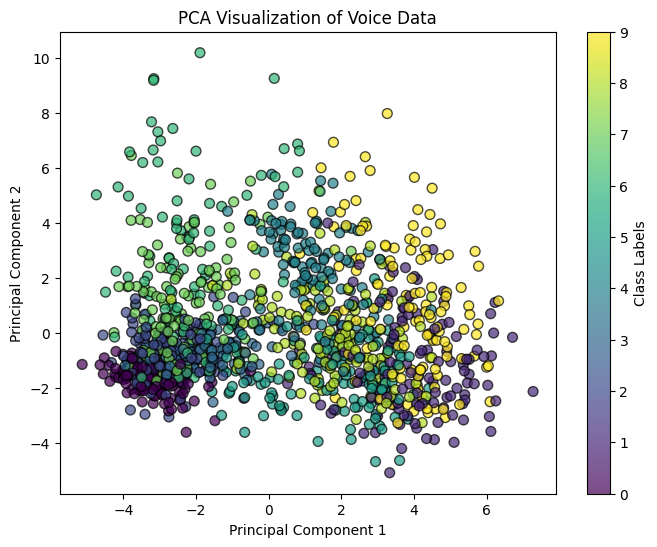

In [82]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
scat = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="viridis", edgecolor='k', s=50, alpha=0.7)
plt.title("PCA Visualization of Voice Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scat, label="Class Labels")
plt.show()

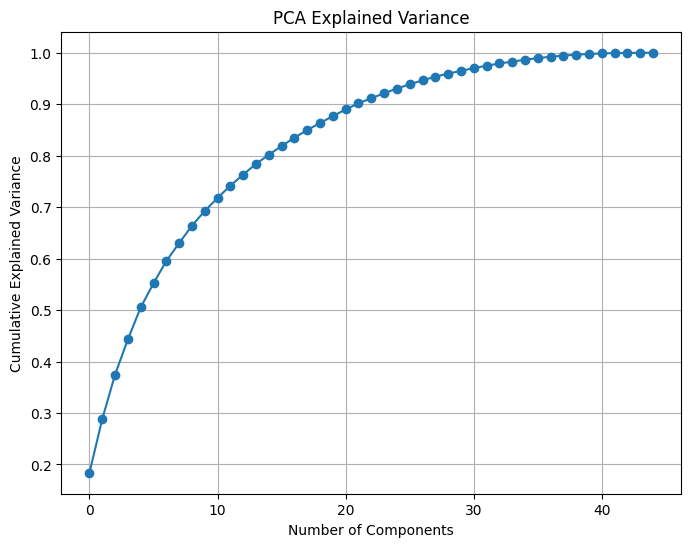

In [11]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()


In [24]:
pca = PCA(n_components=40)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

print(f"Explained Variance Ratio: {sum(pca.explained_variance_ratio_):.4f}")


Explained Variance Ratio: 0.9971


In [65]:
def train_evaluation(X_train, X_test, y_train, y_test):
  models = {
    "SVM": SVC(kernel='rbf', decision_function_shape='ovr', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=500, random_state=42),
  }

  results = {}

  for name, model in models.items():
      model.fit(X_train, y_train)

      y_pred = model.predict(X_test)
      y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

      accuracy = accuracy_score(y_test, y_pred)
      report = classification_report(y_test, y_pred, output_dict=True)
      cm = confusion_matrix(y_test, y_pred)
      roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="micro") if y_prob is not None else None

      results[name] = {
          "Accuracy": accuracy,
          "Classification Report": report,
          "Confusion Matrix": cm,
      }
      results[name]["ROC AUC"] = roc_auc if y_prob is not None else None

      print("\n" + "-" * 30 + f" {name} Results " + "-" * 30 + "\n")
      print(f"{name} Classification Report:")
      print(classification_report(y_test, y_pred))
      print(f"{name} Confusion Matrix:\n{cm}\n")
      print(f"{name} Accuracy: {accuracy:.4f}\n")
      if roc_auc:
        print(f"{name} ROC AUC: {roc_auc:.2f}\n")

      plt.figure(figsize=(7, 5))
      sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(1, 11), yticklabels=range(1, 11))
      plt.xlabel("Predicted Label")
      plt.ylabel("True Label")
      plt.title(f"Confusion Matrix for {name}")
      plt.show()

      if y_prob is not None:
        plt.figure(figsize=(7, 5))
        for i in range(y_prob.shape[1]):
            fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
            auc_score = roc_auc_score(y_test == i, y_prob[:, i])
            plt.plot(fpr, tpr, label=f"Class {i + 1} (AUC = {auc_score:.4f})")

        plt.plot([0, 1], [0, 1], "k--")
        plt.title(f"ROC Curves for {name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        y_test_bin = label_binarize(y_test, classes=range(y_prob.shape[1]))
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
        results[name]["ROC Curve"] = (fpr, tpr)

  plt.figure(figsize=(7, 5))
  for name, result in results.items():
    roc_auc = result.get("ROC AUC")
    if roc_auc is not None:
      fpr, tpr = result.get("ROC Curve")
      plt.plot(fpr, tpr, label=f"{name}, (AUC = {roc_auc:.4f})")

  plt.plot([0, 1], [0, 1], "k--")
  plt.title(f"ROC Curve Comparison")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend()
  plt.show()

  return results


In [17]:
df_batches = select_random_students(df_audio, 3, 5)

datasets = []
for i, df in enumerate(df_batches):
  datasets.append(make_dataset(df))


Processing files: 100%|██████████| 55/55 [01:28<00:00,  1.60s/it]




-------------------------------------------------- BATCH 1 --------------------------------------------------



------------------------------ SVM Results ------------------------------

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        45
           2       1.00      1.00      1.00        45
           3       1.00      1.00      1.00        45
           4       1.00      1.00      1.00        38
           5       1.00      1.00      1.00        45
           6       1.00      1.00      1.00        37
           7       1.00      1.00      1.00        45
           8       0.98      1.00      0.99        45
           9       1.00      0.98      0.99        45

    accuracy                           1.00       435
   macro avg       1.00      1.00      1.00       435
weighted avg       1.00      1.00      1.00       435

SVM Confusion Matrix:
[[

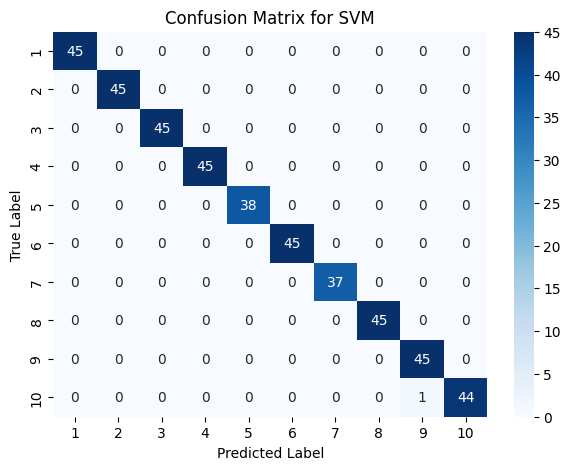

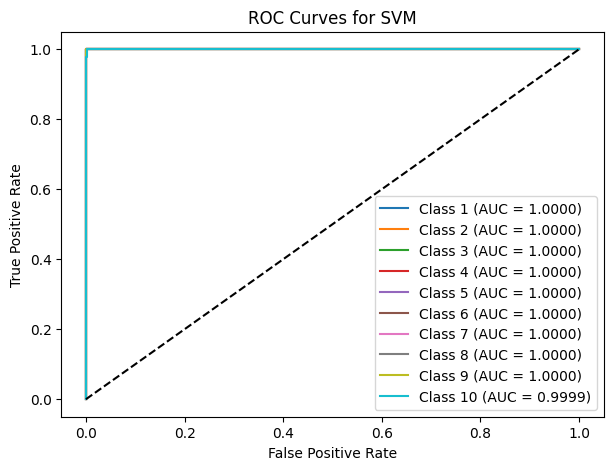


------------------------------ Logistic Regression Results ------------------------------

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       1.00      1.00      1.00        45
           2       0.98      1.00      0.99        45
           3       1.00      1.00      1.00        45
           4       1.00      1.00      1.00        38
           5       1.00      0.98      0.99        45
           6       1.00      1.00      1.00        37
           7       1.00      0.98      0.99        45
           8       0.98      0.96      0.97        45
           9       0.96      0.98      0.97        45

    accuracy                           0.99       435
   macro avg       0.99      0.99      0.99       435
weighted avg       0.99      0.99      0.99       435

Logistic Regression Confusion Matrix:
[[45  0  0  0  0  0  0  0  0  0]
 [ 0 45  0  0  0  0  0  0  0  0]
 [

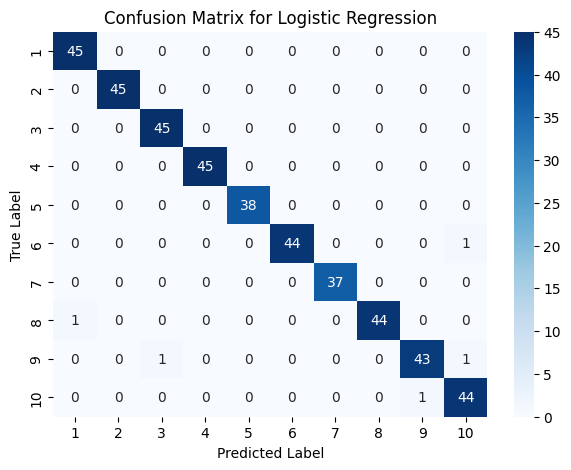

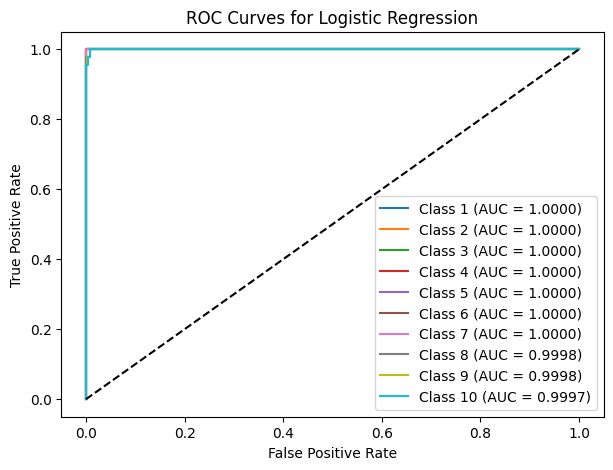


------------------------------ KNN Results ------------------------------

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       0.98      0.98      0.98        45
           2       1.00      1.00      1.00        45
           3       1.00      1.00      1.00        45
           4       0.97      1.00      0.99        38
           5       0.94      0.98      0.96        45
           6       1.00      0.97      0.99        37
           7       0.96      0.98      0.97        45
           8       1.00      0.91      0.95        45
           9       0.96      0.96      0.96        45

    accuracy                           0.98       435
   macro avg       0.98      0.98      0.98       435
weighted avg       0.98      0.98      0.98       435

KNN Confusion Matrix:
[[45  0  0  0  0  0  0  0  0  0]
 [ 0 44  0  0  0  1  0  0  0  0]
 [ 0  0 45  0  0  0  0  0  0  0]
 [ 0  0  0 45  0 

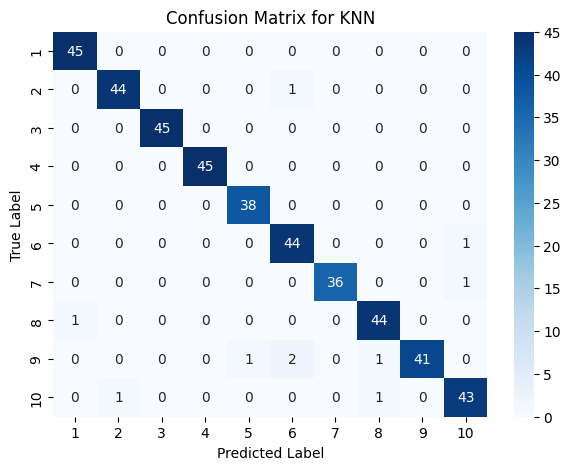

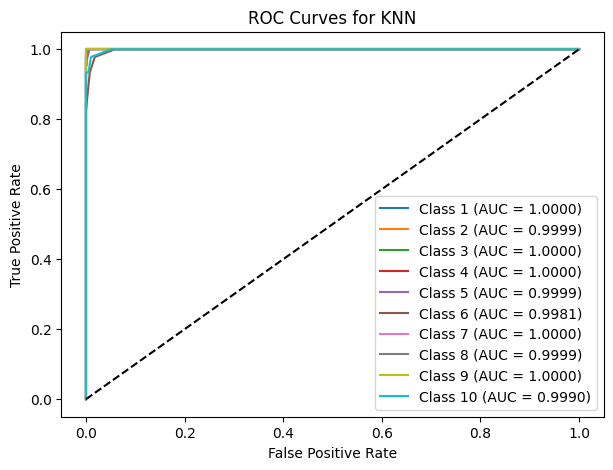


------------------------------ MLP Results ------------------------------

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       1.00      1.00      1.00        45
           2       1.00      0.98      0.99        45
           3       1.00      1.00      1.00        45
           4       1.00      1.00      1.00        38
           5       0.98      1.00      0.99        45
           6       1.00      1.00      1.00        37
           7       1.00      0.98      0.99        45
           8       0.98      0.98      0.98        45
           9       0.98      0.98      0.98        45

    accuracy                           0.99       435
   macro avg       0.99      0.99      0.99       435
weighted avg       0.99      0.99      0.99       435

MLP Confusion Matrix:
[[45  0  0  0  0  0  0  0  0  0]
 [ 0 45  0  0  0  0  0  0  0  0]
 [ 0  0 44  0  0  1  0  0  0  0]
 [ 0  0  0 45  0 

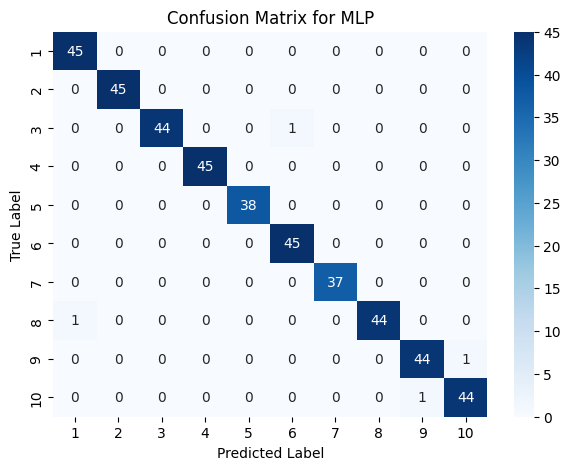

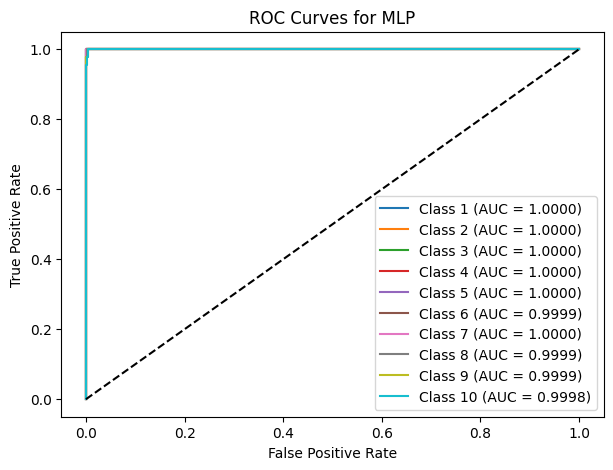

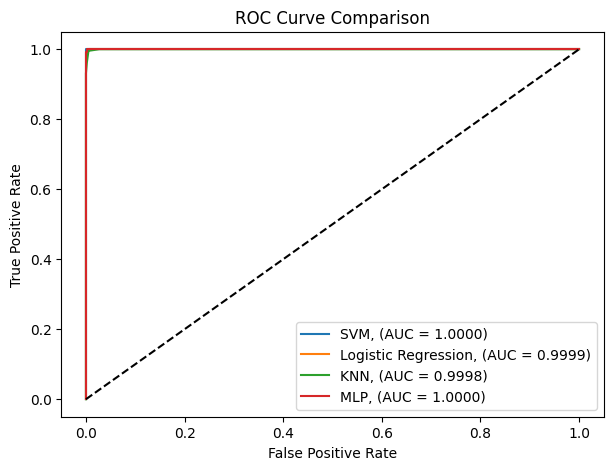



-------------------------------------------------- BATCH 2 --------------------------------------------------



------------------------------ SVM Results ------------------------------

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        45
           1       0.95      0.97      0.96        38
           2       0.98      1.00      0.99        45
           3       1.00      1.00      1.00        45
           4       0.96      1.00      0.98        45
           5       1.00      0.91      0.95        22
           6       0.98      0.98      0.98        45
           7       1.00      1.00      1.00        45
           8       1.00      0.96      0.98        45
           9       1.00      1.00      1.00        29

    accuracy                           0.98       404
   macro avg       0.98      0.98      0.98       404
weighted avg       0.98      0.98      0.98       404

SVM Confusion Matrix:
[[

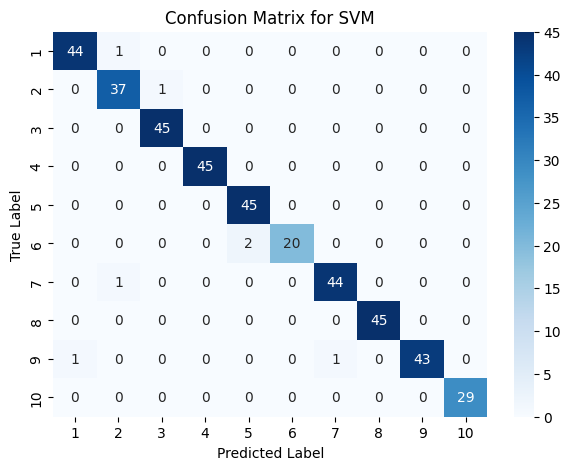

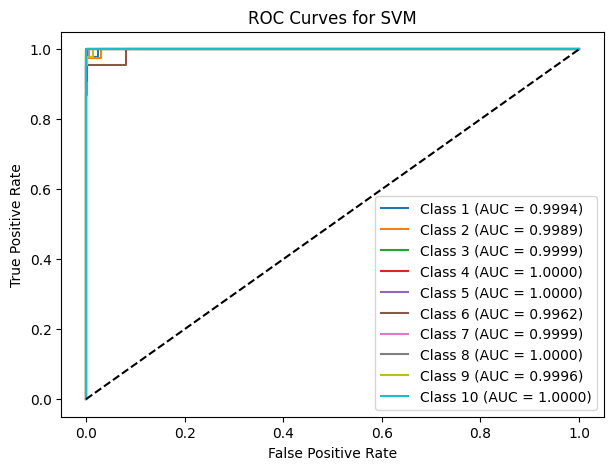


------------------------------ Logistic Regression Results ------------------------------

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       0.90      0.95      0.92        38
           2       0.96      1.00      0.98        45
           3       0.98      0.98      0.98        45
           4       0.98      1.00      0.99        45
           5       1.00      0.95      0.98        22
           6       1.00      1.00      1.00        45
           7       1.00      0.96      0.98        45
           8       0.95      0.93      0.94        45
           9       1.00      1.00      1.00        29

    accuracy                           0.97       404
   macro avg       0.97      0.97      0.97       404
weighted avg       0.97      0.97      0.97       404

Logistic Regression Confusion Matrix:
[[43  2  0  0  0  0  0  0  0  0]
 [ 0 36  1  0  0  0  0  0  1  0]
 [

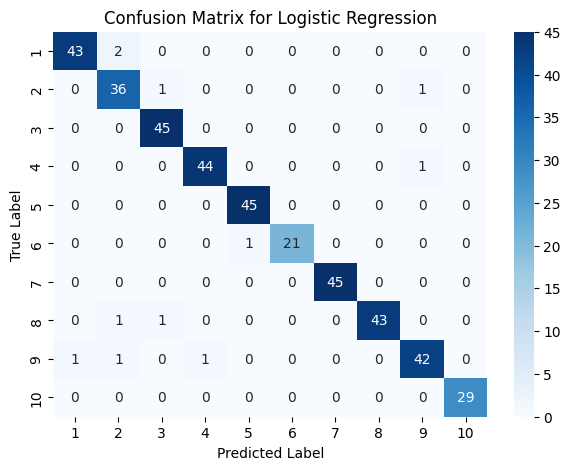

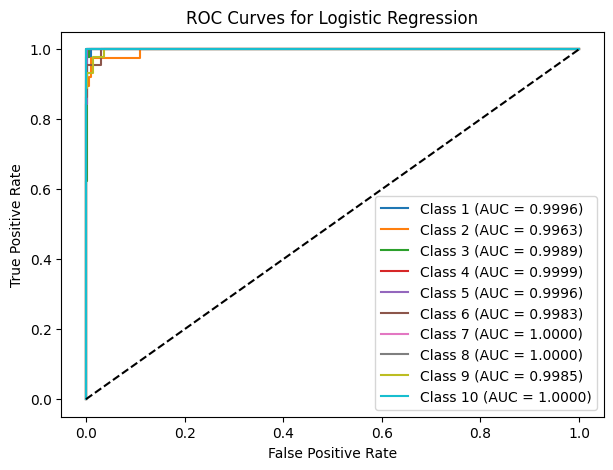


------------------------------ KNN Results ------------------------------

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        45
           1       0.94      0.89      0.92        38
           2       0.92      1.00      0.96        45
           3       0.96      0.98      0.97        45
           4       0.92      1.00      0.96        45
           5       0.77      0.91      0.83        22
           6       0.97      0.84      0.90        45
           7       1.00      0.93      0.97        45
           8       1.00      0.91      0.95        45
           9       1.00      1.00      1.00        29

    accuracy                           0.95       404
   macro avg       0.94      0.95      0.94       404
weighted avg       0.95      0.95      0.95       404

KNN Confusion Matrix:
[[45  0  0  0  0  0  0  0  0  0]
 [ 2 34  2  0  0  0  0  0  0  0]
 [ 0  0 45  0  0  0  0  0  0  0]
 [ 0  1  0 44  0 

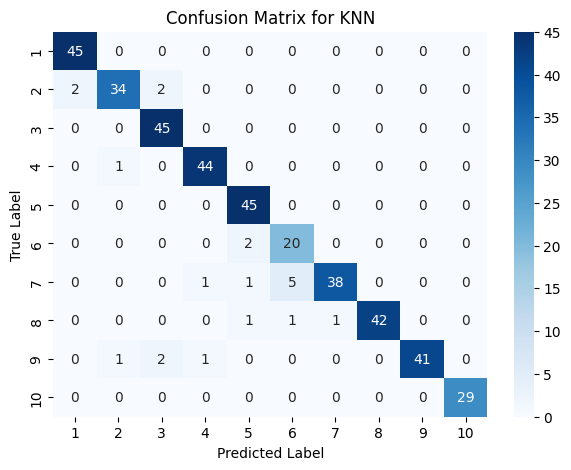

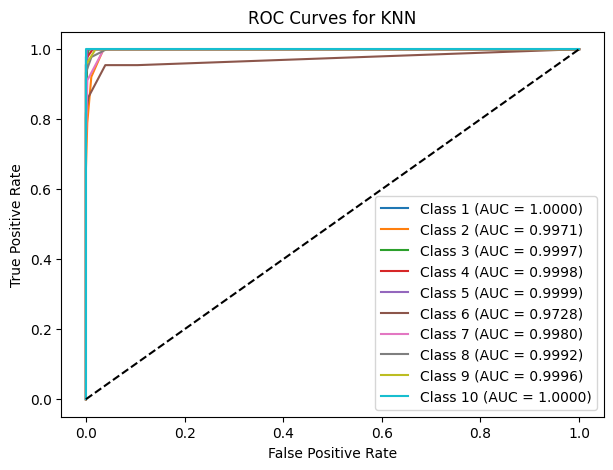


------------------------------ MLP Results ------------------------------

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        45
           1       0.92      0.92      0.92        38
           2       0.98      1.00      0.99        45
           3       1.00      0.98      0.99        45
           4       0.98      1.00      0.99        45
           5       1.00      0.91      0.95        22
           6       0.98      0.98      0.98        45
           7       1.00      1.00      1.00        45
           8       0.93      0.93      0.93        45
           9       0.97      1.00      0.98        29

    accuracy                           0.97       404
   macro avg       0.97      0.97      0.97       404
weighted avg       0.97      0.97      0.97       404

MLP Confusion Matrix:
[[44  1  0  0  0  0  0  0  0  0]
 [ 0 35  1  0  0  0  0  0  2  0]
 [ 0  0 45  0  0  0  0  0  0  0]
 [ 0  0  0 44  0 

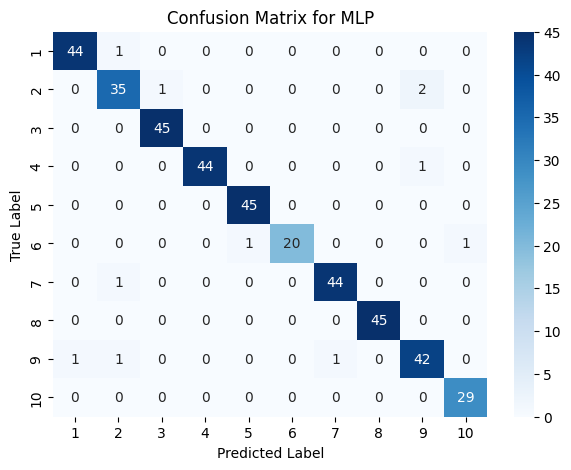

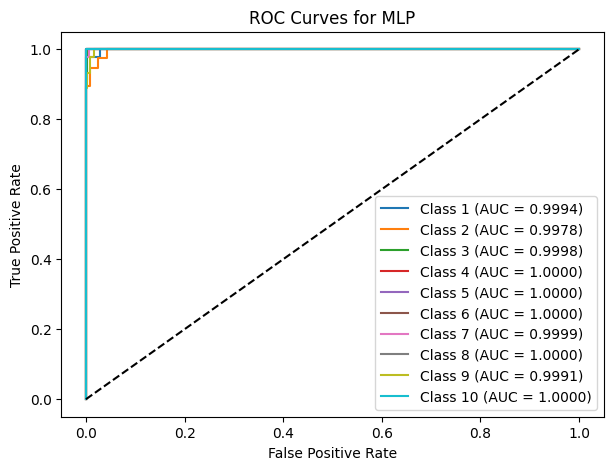

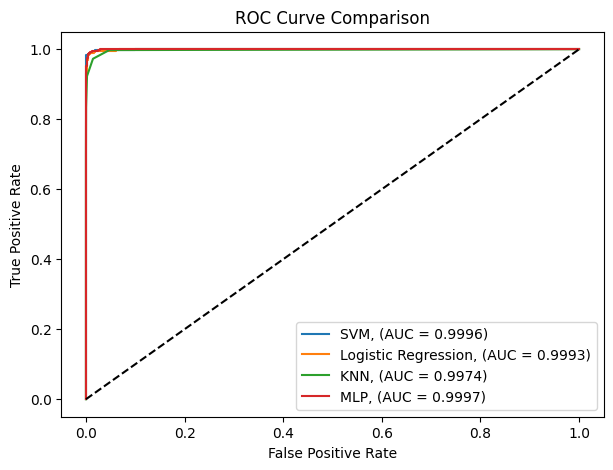



-------------------------------------------------- BATCH 3 --------------------------------------------------



------------------------------ SVM Results ------------------------------

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.98      1.00      0.99        45
           2       1.00      1.00      1.00        45
           3       1.00      0.96      0.98        45
           4       0.97      1.00      0.98        30
           5       0.96      1.00      0.98        23
           6       1.00      1.00      1.00        45
           7       1.00      0.98      0.99        45
           8       0.98      1.00      0.99        42
           9       1.00      0.98      0.99        45

    accuracy                           0.99       410
   macro avg       0.99      0.99      0.99       410
weighted avg       0.99      0.99      0.99       410

SVM Confusion Matrix:
[[

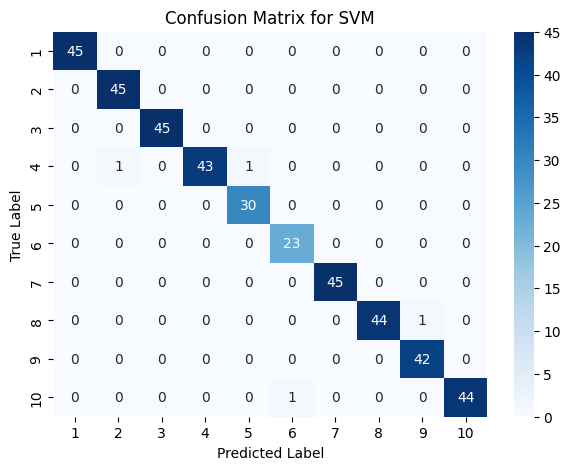

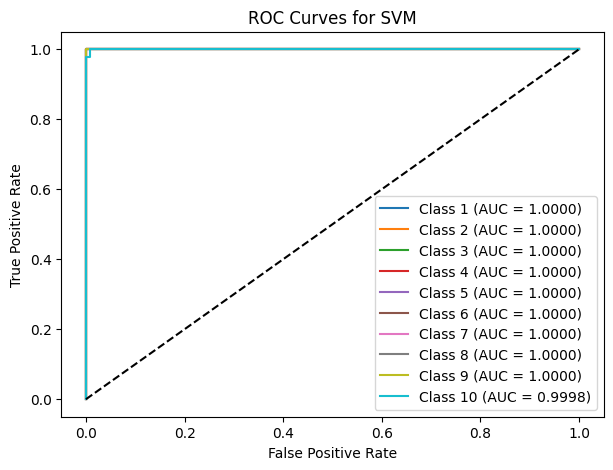


------------------------------ Logistic Regression Results ------------------------------

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       1.00      1.00      1.00        45
           2       1.00      1.00      1.00        45
           3       1.00      1.00      1.00        45
           4       0.97      1.00      0.98        30
           5       0.96      1.00      0.98        23
           6       1.00      1.00      1.00        45
           7       1.00      1.00      1.00        45
           8       1.00      1.00      1.00        42
           9       1.00      0.98      0.99        45

    accuracy                           1.00       410
   macro avg       0.99      1.00      0.99       410
weighted avg       1.00      1.00      1.00       410

Logistic Regression Confusion Matrix:
[[44  0  0  0  1  0  0  0  0  0]
 [ 0 45  0  0  0  0  0  0  0  0]
 [

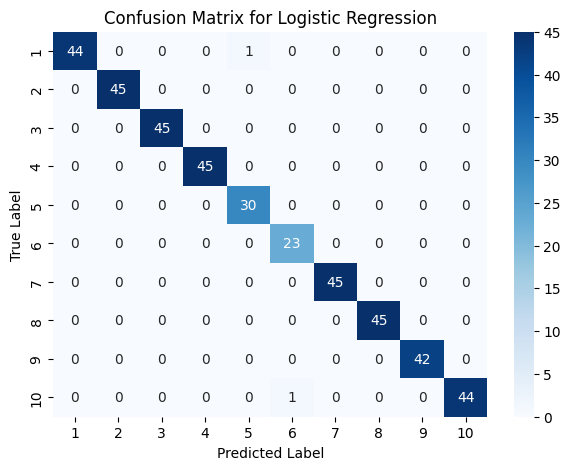

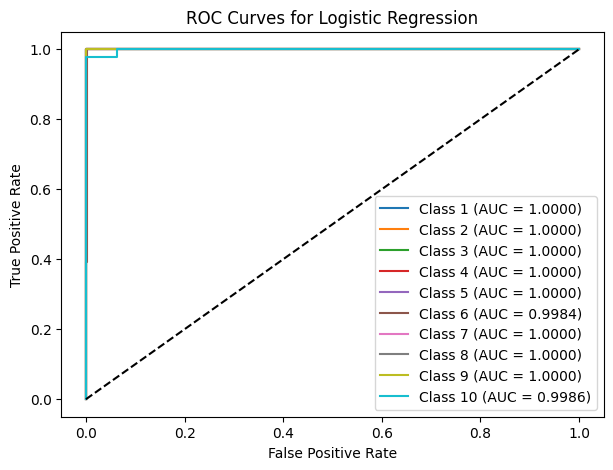


------------------------------ KNN Results ------------------------------

KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      0.91      0.95        45
           2       0.98      1.00      0.99        45
           3       1.00      0.91      0.95        45
           4       0.88      1.00      0.94        30
           5       0.88      1.00      0.94        23
           6       0.94      1.00      0.97        45
           7       1.00      0.98      0.99        45
           8       0.98      0.98      0.98        42
           9       1.00      0.96      0.98        45

    accuracy                           0.97       410
   macro avg       0.97      0.97      0.97       410
weighted avg       0.97      0.97      0.97       410

KNN Confusion Matrix:
[[45  0  0  0  0  0  0  0  0  0]
 [ 0 41  1  0  0  0  3  0  0  0]
 [ 0  0 45  0  0  0  0  0  0  0]
 [ 0  0  0 41  4 

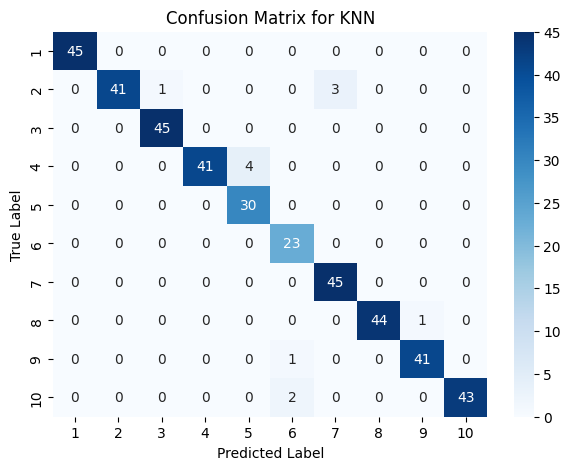

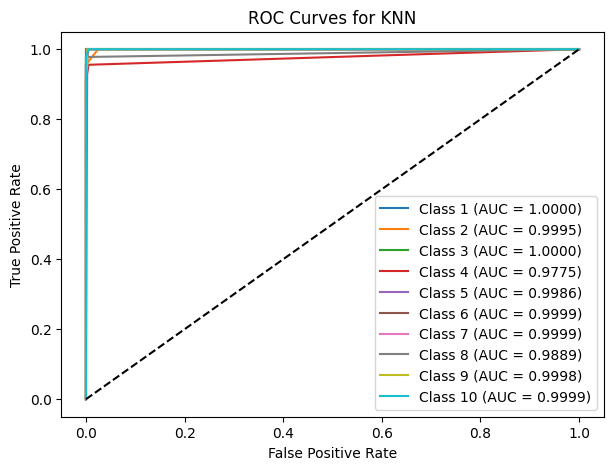


------------------------------ MLP Results ------------------------------

MLP Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       1.00      1.00      1.00        45
           2       0.98      1.00      0.99        45
           3       1.00      1.00      1.00        45
           4       1.00      1.00      1.00        30
           5       0.96      1.00      0.98        23
           6       1.00      1.00      1.00        45
           7       0.98      1.00      0.99        45
           8       1.00      0.98      0.99        42
           9       1.00      0.98      0.99        45

    accuracy                           0.99       410
   macro avg       0.99      0.99      0.99       410
weighted avg       0.99      0.99      0.99       410

MLP Confusion Matrix:
[[44  0  1  0  0  0  0  0  0  0]
 [ 0 45  0  0  0  0  0  0  0  0]
 [ 0  0 45  0  0  0  0  0  0  0]
 [ 0  0  0 45  0 

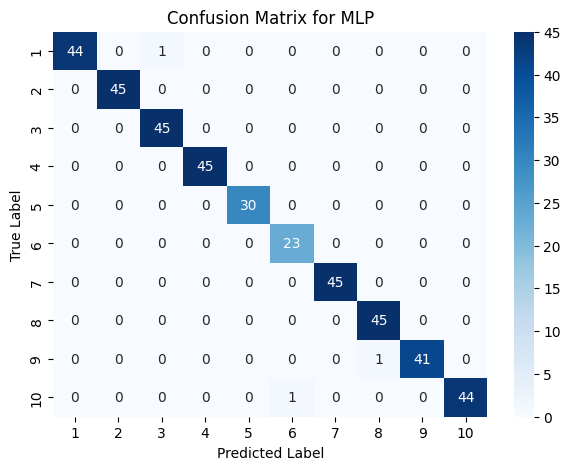

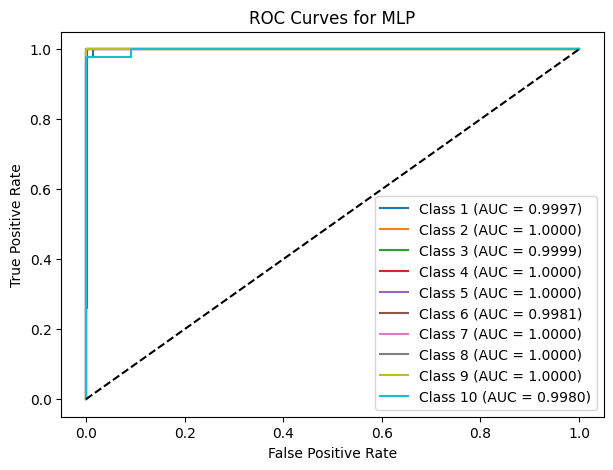

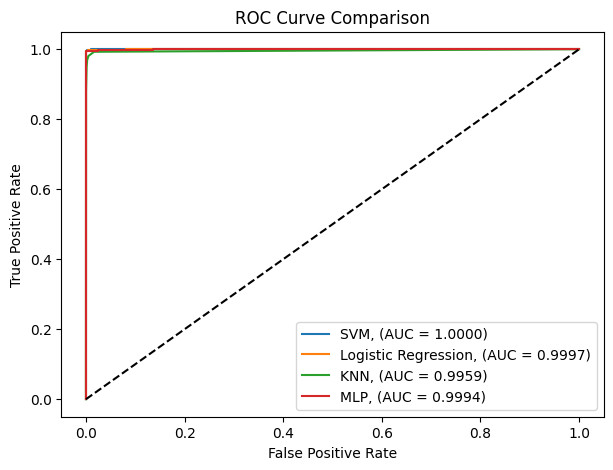

In [66]:
results = []

for i, (X, y, class2label) in enumerate(datasets):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  pca = PCA(n_components=40)
  X_train_reduced = pca.fit_transform(X_train)
  X_test_reduced = pca.transform(X_test)

  print("\n\n" + "-" *50 + f" BATCH {i + 1} " + "-" * 50 + "\n\n")
  results.append(train_evaluation(X_train_reduced, X_test_reduced, y_train, y_test))